<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [113]:
import pandas as pd

## Step 2. Import the dataset

In [114]:
df = pd.read_csv("50_Startups.csv")

In [115]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


## Step 3 . Check the State Column

In [116]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [117]:
x = df.iloc[::,:4:]
y = df.iloc[::,4::]

In [118]:
x

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [119]:
x1 = pd.get_dummies(x, columns=["State"], drop_first=True)

In [120]:
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [ ]:
# Already Performed using | drop_first =True

## Step 7 Splitting dataset in to Train and Test

In [122]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x1, y, test_size = 0.2, random_state=42)
X_train.shape

(40, 5)

## Step 8  Import LinearRegression model from linear_model family 

In [123]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()


## Step 9  Fit the data

In [124]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Step 10  Predict the data

In [125]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)


## Step 11  Display Result

In [126]:
# y_test and y_predict
import matplotlib.pyplot as plt

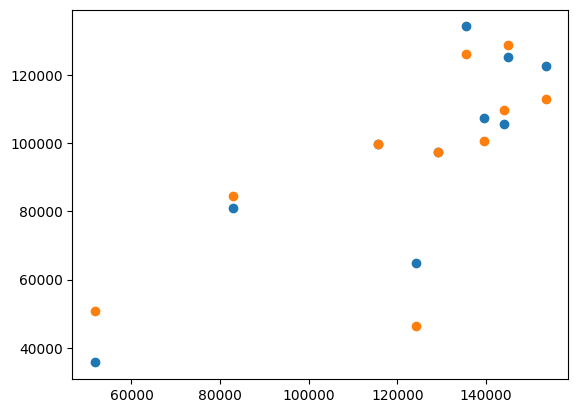

In [127]:
plt.scatter(X_test['Administration'], y_test)
plt.scatter(X_test['Administration'], y_pred)

## RSS

In [128]:
import numpy as np


In [129]:
np.sum((y_test.values - y_pred) ** 2)

np.float64(820103630.443011)

In [130]:
len(y_test)

10

In [131]:
from sklearn.metrics import mean_squared_error

In [132]:
mean_squared_error(y_test, y_pred)

82010363.04430111

## R Square

In [133]:
from sklearn.metrics import r2_score

In [134]:
r2_score(y_test, y_pred)

0.8987266414328636

## Now use Polynomial Regression on Position_Salaries dataset

In [135]:
df2 = pd.read_csv("Position_Salaries.csv")
df2.shape

(10, 3)

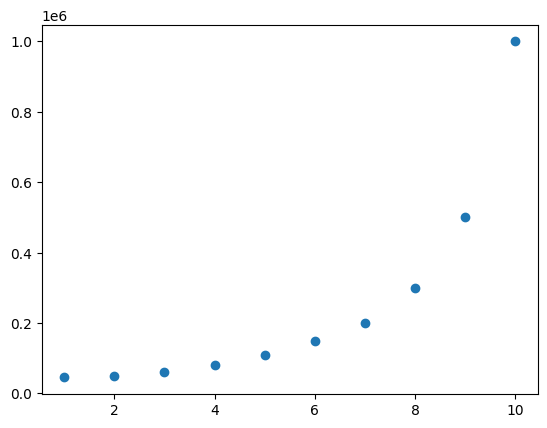

In [136]:
plt.scatter(df2['Level'], df2['Salary'])

In [137]:
x=df2.iloc[::,1:2:]
y=df2['Salary']
x

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [144]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)
x_train

,Level
0,1
7,8
2,3
9,10
4,5
3,4
6,7


In [145]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x_train)
x_poly

array([[  1.,   1.,   1.],
       [  1.,   8.,  64.],
       [  1.,   3.,   9.],
       [  1.,  10., 100.],
       [  1.,   5.,  25.],
       [  1.,   4.,  16.],
       [  1.,   7.,  49.]])

In [165]:
from sklearn.linear_model import LinearRegression

In [166]:
model = LinearRegression()

In [170]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [168]:
y_pred = model.predict(x_test)